## Running kinGEMs Pipeline on $E. coli$ iML1515 Model

In [11]:

%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('distributed').setLevel(logging.ERROR)
try:
    import gurobipy
    gurobipy.setParam('OutputFlag', 0)
except ImportError:
    pass
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import cobra # type: ignore
import numpy as np # type: ignore
from datetime import datetime
import random
from cobra.io import write_sbml_model # type: ignore
import cobra as cb

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

# Import kinGEMs components
import kinGEMs
from kinGEMs.dataset import load_model, convert_to_irreversible, prepare_model_data, retrieve_sequences, map_metabolites, merge_substrate_sequences, process_merged_data_with_folds, process_kcat_predictions, assign_kcats_to_model, format_kcats_like_gpr, annotate_model_with_kcat_and_gpr
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, validate_enzyme_constraints
from kinGEMs.modeling.tuning import simulated_annealing, analyze_kcat_changes
from kinGEMs.modeling.fva import flux_variability_analysis, plot_flux_variability, plot_cumulative_fvi_distribution, flux_variability_analysis_parallel


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Set your GEM name here

In [2]:

# === Configuration ===
organism_strain_GEMname = "ecoli_iML1515" # Update this
organism = "E coli" # Update this 
run_id = f"{organism_strain_GEMname}_{datetime.today().strftime('%Y%m%d')}_{random.randint(1000, 9999)}"

# Directories
data_dir = "../data"
raw_data_dir = os.path.join(data_dir, "raw")
interim_data_dir = os.path.join(data_dir, "interim")
interim_data_dir_spec = os.path.join(interim_data_dir, f"{organism_strain_GEMname}")
processed_data_dir = os.path.join(data_dir, "processed")
processed_data_dir_spec = os.path.join(processed_data_dir, f"{organism_strain_GEMname}")
CPIPred_data_dir = os.path.join(interim_data_dir, "CPI-Pred predictions")
results_dir = os.path.join(os.getcwd(), "results")
tuning_results_dir = os.path.join(results_dir, "tuning_results", run_id)
os.makedirs(tuning_results_dir, exist_ok=True)

# Input files
model_path = os.path.join(raw_data_dir, "iML1515_GEM.xml") # Update this
predictions_csv_path = os.path.join(CPIPred_data_dir, f"X06A_kinGEMs_{organism_strain_GEMname}_predictions.csv")

# Output files
substrates_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_substrates.csv")
sequences_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_sequences.csv")
merged_data_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_merged_data.csv")
processed_data_output = os.path.join(processed_data_dir_spec, f"{organism_strain_GEMname}_processed_data.csv")

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_core_75p37M' # Update this
enzyme_upper_bound = 0.15


### Step 1: Preparing and processing model data

In [3]:

print("=== Step 1: Preparing model data ===")
model, substrate_df, sequences_df = prepare_model_data(
    model_path=model_path,
    substrates_output=substrates_output,
    sequences_output=sequences_output,
    organism=organism
)


=== Step 1: Preparing model data ===
Loaded model with 2712 reactions and 1877 metabolites
Extracted 6194 substrate-reaction-direction pairs
Loaded model with 2712 reactions and 1877 metabolites
Extracted 6194 substrate-reaction-direction pairs


2025-08-19 15:52:35,721 - kinGEMs.dataset - INFO - There are 1814 substrates in the GEM.
2025-08-19 15:52:35,755 - kinGEMs.dataset - INFO - -----------------------------
2025-08-19 15:52:35,756 - kinGEMs.dataset - INFO - Mapping substrate: ala__D_c
2025-08-19 15:52:35,755 - kinGEMs.dataset - INFO - -----------------------------
2025-08-19 15:52:35,756 - kinGEMs.dataset - INFO - Mapping substrate: ala__D_c
2025-08-19 15:52:35,795 - kinGEMs.dataset - INFO - BiGG Name: D-Alanine
2025-08-19 15:52:35,838 - kinGEMs.dataset - INFO - SMILES found in SEED: C[C@@H]([NH3+])C(=O)[O-]
2025-08-19 15:52:35,838 - kinGEMs.dataset - INFO - -----------------------------
2025-08-19 15:52:35,838 - kinGEMs.dataset - INFO - Mapping substrate: pydx5p_c
2025-08-19 15:52:35,795 - kinGEMs.dataset - INFO - BiGG Name: D-Alanine
2025-08-19 15:52:35,838 - kinGEMs.dataset - INFO - SMILES found in SEED: C[C@@H]([NH3+])C(=O)[O-]
2025-08-19 15:52:35,838 - kinGEMs.dataset - INFO - -----------------------------
2025-08-19

Mapped metabolites to SMILES (5449 found)


2025-08-19 16:00:59,539 - root - WARNING - No sequence found for gene s0001


Retrieved 1515 protein sequences


In [6]:
model = irrev_model

### Step 2: Merging substrate and sequence data

In [7]:

print("=== Step 2: Merging substrate and sequence data ===")

# substrate_df = pd.read_csv(substrates_output)
# sequences_df = pd.read_csv(sequences_output)
# model = load_model(model_path)

merged_data = merge_substrate_sequences(
    substrate_df=substrate_df,
    sequences_df=sequences_df,
    model=model,
    output_path=merged_data_output
)


=== Step 2: Merging substrate and sequence data ===


### Step 3: Processing CPI-Pred kcat values

In [8]:

print("=== Step 3: Processing CPI-Pred kcat values & annotating model ===")
processed_data = process_kcat_predictions(
    merged_df=merged_data,
    predictions_csv_path=predictions_csv_path,
    output_path=processed_data_output
)

model = annotate_model_with_kcat_and_gpr(
    model=model,
    df=processed_data
)


=== Step 3: Processing CPI-Pred kcat values & annotating model ===


## Step 4: Optimization (FBA Sanity Check + kinGEMs)

make sure code below works first

In [9]:
print("=== Step 4: Running optimization with kcat constraints ===")
(solution_value, df_FBA, gene_sequences_dict, _)=run_optimization_with_dataframe(
    model=model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True,
    verbose=False)

print("Biomass value: ", solution_value)

=== Step 4: Running optimization with kcat constraints ===
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Biomass value:  0.02959882354850739


### Step 5: Simulated Annealing

=== Step 5: Running simulated annealing ===
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M

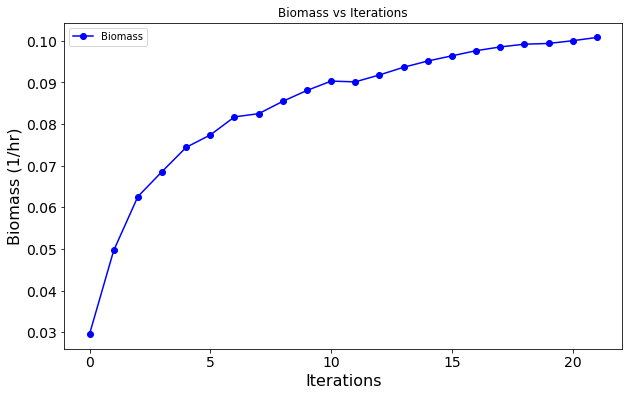

In [12]:

print("=== Step 5: Running simulated annealing ===")
temperature = 1.0
cooling_rate = 0.95
min_temperature = 0.01
max_iterations = 100
max_unchanged_iterations = 4
change_threshold = 0.009
biomass_goal = 0.5

kcat_dict, top_targets, df_new, iterations, biomasses, df_FBA = simulated_annealing(
    model=model,
    processed_data=processed_data,
    biomass_reaction=biomass_reaction,
    objective_value=biomass_goal,
    gene_sequences_dict=gene_sequences_dict,      # ← new
    output_dir=tuning_results_dir,
    enzyme_fraction=enzyme_upper_bound,
    temperature=temperature,
    cooling_rate=cooling_rate,
    min_temperature=min_temperature,
    max_iterations=max_iterations,
    max_unchanged_iterations=max_unchanged_iterations,
    change_threshold=change_threshold
)

print(f"Final biomass: {biomasses[-1]:.4f}")
print(f"Improvement: {(biomasses[-1] - biomasses[0]) / biomasses[0] * 100:.1f}%")
print("Top 10 enzymes by mass contribution:")
print(top_targets[['Reactions','Single_gene','enzyme_mass']])


### Step 6: FVA 

In [ ]:

print("=== Step 6: Running Flux Variability Analysis ===")
fva_results_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_results.csv")
fva_plot_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_flux_range_plot.png")
fva_cumulative_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_cumulative_plot.png")

fva_results, _, _ = flux_variability_analysis(
    model=model,
    processed_df=df_new,
    biomass_reaction=biomass_reaction,
    output_file=fva_results_path,
    enzyme_upper_bound=enzyme_upper_bound
)

# Plot standard FVA range
fig = plot_flux_variability(fva_results, output_file=fva_plot_path)

# Plot cumulative distribution
plot_cumulative_fvi_distribution(
    dfs=[fva_results],
    labels=[organism_strain_GEMname],
    output_file=fva_cumulative_path
)


=== Step 6: Running Flux Variability Analysis ===
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25
Read LP format model from file C:\Users\Rana\AppData\Local\Temp\tmpurgi09gp.pyomo.lp
Reading time = 0.03 seconds
x1: 6009 rows, 4229 columns, 24922 nonzeros
Gurobi Optimizer version 10.0.1 build v10.0.1rc0 (win64)

CPU model: 12th Gen Intel(R) Core(TM) i7-12700, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 6009 rows, 4229 columns and 24922 nonzeros
Model fingerprint: 0x60b4828d
Coefficient statistics:
  Matrix range     [3e-07, 4e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e-01, 1e+03]
  RHS range        [0e+00, 0e+00]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve 

In [ ]:
# Plot standard FVA range
fig = plot_flux_variability(fva_results, output_file=fva_plot_path)

# Plot cumulative distribution
plot_cumulative_fvi_distribution(
    dfs=[fva_results],
    labels=[organism_strain_GEMname],
    output_file=fva_cumulative_path
)

### Step 7: Save Final Model

In [ ]:
# Define output path for final GEM
model_output_dir = os.path.join("models")
os.makedirs(model_output_dir, exist_ok=True)
model_output_path = os.path.join(model_output_dir, f"{run_id}.xml")

# After simulated annealing
model_with_kcats = assign_kcats_to_model(model, df_new)

# Preview:
format_kcats_like_gpr(model_with_kcats.reactions.get_by_id("PGI"))


# Save the final irreversible model
write_sbml_model(model_with_kcats, model_output_path)

print(f"Final GEM saved to: {model_output_path}")